# 1. Imports and Setup

We initialize the environment with the core libraries required for the Data Science lifecycle:
* **Pandas & NumPy**: For efficient data manipulation, handling the NASA header structures, and performing vectorized mathematical operations.
* **Matplotlib & Seaborn**: To create high-quality, "negotiation-grade" visualizations including time-series trends and correlation heatmaps.
* **SciPy (Stats)**: Utilized specifically for outlier detection via Z-score calculations and statistical validation of climate trends.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('default')

# 2. Load Datasets

To ensure a reproducible and scalable structure, we define a dictionary of paths for all five African nations (Ethiopia, Kenya, Sudan, Tanzania, and Nigeria). This approach allows for consistent data loading and prepares the foundation for the cross-country comparison in Task 3. 

> **Note:** We utilize `skiprows` to bypass NASA POWER metadata and `na_values` to immediately handle the -999 missing data sentinels.

In [2]:
countries = {
    "ethiopia": "../data/ethiopia.csv",
    "kenya": "../data/kenya.csv",
    "sudan": "../data/sudan.csv",
    "tanzania": "../data/tanzania.csv",
    "nigeria": "../data/nigeria.csv"
}

dfs = {}

for country, path in countries.items():
    df = pd.read_csv(path)
    df["Country"] = country.capitalize()
    dfs[country] = df

# 3. Target Country Selection: Nigeria
While the codebase is designed for multi-country analysis, this notebook focuses specifically on Nigeria. As a key regional leader and West African partner for the COP32 summit in Addis Ababa, Nigeria's climate data is essential for understanding the transition between the Gulf of Guinea's maritime tropical systems and the Sahelian arid cycles. We create a dedicated dataframe (df) for Nigeria to perform deep-dive profiling and cleaning, focusing on its distinct latitudinal climatic gradient, the influence of the West African Monsoon, and the diverse climatology ranging from the high-precipitation mangrove swamps of the south to the semi-arid grasslands of the north.

In [3]:
df = dfs["nigeria"].copy()
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria


# 4. Data Parsing

**Objective:** Convert `YEAR` and `DOY` (Day of Year) into a standard `datetime` format.

**Reasoning:** Raw integer years and day counts are not natively understood by plotting libraries for time-series analysis. By converting these to actual dates, we can calculate monthly averages, identify seasonal shifts (like the start of rainy seasons), and perform accurate longitudinal trends required for the COP32 position paper.

In [4]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

# 5. Handling NASA Missing Value Sentinels

**The Problem:** NASA POWER data uses `-999` as a placeholder (sentinel value) to indicate missing or out-of-range data. Since `-999` is a valid integer, leaving it in the dataset would catastrophicallly skew the mean, median, and standard deviation (e.g., pulling a $25°C$ average down to a negative value).

**The Solution:** We replace all instances of `-999` with `NaN` (Not a Number). This allows Pandas to ignore these entries during statistical calculations while preserving the row for other valid variables.

In [5]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.23,29.25,22.06,7.19,0.00,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,2015,2,26.16,29.41,22.87,6.54,0.00,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,2015,3,25.66,29.02,22.63,6.39,0.00,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,2015,4,24.11,27.27,19.92,7.35,0.00,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,2015,5,23.40,27.28,18.18,9.10,0.00,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,29.05,32.43,26.69,5.74,2.82,76.60,2.35,3.39,100.58,19.10,Nigeria,2026-03-27,3
4104,2026,87,28.72,31.98,27.14,4.84,5.19,79.61,2.55,3.17,100.64,19.49,Nigeria,2026-03-28,3
4105,2026,88,27.72,29.53,26.21,3.32,1.43,82.83,1.10,1.78,100.61,19.22,Nigeria,2026-03-29,3
4106,2026,89,28.42,31.17,26.36,4.81,0.85,77.73,2.30,3.40,100.53,18.73,Nigeria,2026-03-30,3


# 6. Duplicate Check

**Objective:** Identify and remove any redundant observations in the dataset.

**Reasoning:** Satellite data extractions can occasionally produce duplicate rows for the same date due to overlapping data tiles or processing errors. Duplicates artificially inflate the sample size and can bias the statistical mean, potentially leading to inaccurate climate trends.

In [6]:
duplicates = df.duplicated().sum()
print("Duplicates:", duplicates)

df = df.drop_duplicates()

Duplicates: 0


# 7. Summary Statistics Interpretation (Tanzania)

**Objective:** To establish a climatological baseline for Nigeria (2015–2026).

**Analysis:**

**Tropical Humid Baseline:** Nigeria exhibits a warm and consistent thermal profile, with a mean daily temperature ($T2M$) of 26.66°C. Much like Tanzania, the mean diurnal range ($T2M\_RANGE$) is relatively constrained at 4.03°C. This suggests a climate heavily regulated by atmospheric moisture and the influence of the Gulf of Guinea, which prevents the radical temperature drops at night often seen in the more northern Sahelian regions.

**Extreme Monsoonal Rainfall:** Nigeria’s precipitation data reveals an extraordinary capacity for high-intensity events. While the daily mean is 4.21 mm, the maximum recorded event reaches a massive 166.10 mm. This is the highest single-day peak observed in our multi-country study thus far, significantly exceeding even Tanzania's 122 mm. Such extreme outliers highlight Nigeria's acute vulnerability to flash flooding and the destructive potential of the West African Monsoon.

**Saturated Atmosphere & Low Wind Speeds:** Nigeria presents the highest average relative humidity in the study at 85.24%. This near-saturation state is reflected in the high specific humidity ($QV2M$) mean of 18.56 g/kg. Interestingly, wind speeds are the lowest among the compared nations (mean 2.22 m/s), suggesting that atmospheric energy is more often expressed through convective rainfall and vertical storm development rather than sustained horizontal surface winds. This high-humidity, low-wind environment creates a significant "heat index" burden, where the perceived temperature is often much higher than the recorded $T2M$.

In [7]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


# 8. Missing Value Percentage Report

**Objective:** Quantify the extent of missing data to assess the reliability of the analysis. 

**Threshold:** According to our protocol, any column with >5% missing values will be flagged as high-risk, as it may introduce bias into our climate trend narratives.

In [8]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Percentage": missing_percent
})

missing_df

,Missing Count,Percentage
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


# 9. Outlier Detection (Z-Score)

**Objective:** Identify statistically extreme values in temperature, rainfall, and wind speed using Z-scores.

**Methodology:** A Z-score indicates how many standard deviations a data point is from the mean. We flag any observation with a $|Z| > 3$ as a potential outlier.

**Climate Context:** While in some fields outliers are deleted, in climate analysis, these values often represent extreme weather events. We will count them to understand the frequency of "shocks" to the Nigerian climate system.

In [9]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(stats.zscore(df[cols], nan_policy='omit'))

outliers = (z_scores > 3).sum()
print(outliers)

297


# 10. Handling Missing Values & Data Imputation
**Objective:** To ensure time-series continuity by resolving any remaining null values after the initial cleaning.

**Methodology:**

**Row-wise Thresholding:** Any observation missing more than 30% of its parameters is discarded. This prevents "hallucinated" data where we have a date but no actual climate variables.

**Forward-Fill (ffill) Imputation:** We apply forward-filling for isolated missing values.

**Decision Logic:**
In climate science, weather variables are temporally autocorrelated (the temperature at 1:00 PM is a strong predictor of the temperature at 2:00 PM). Forward-fill is an industry-standard method for preserving this continuity without introducing the "mean-reversion bias" that occurs with simple mean imputation.

In [10]:
df = df.dropna(thresh=int(df.shape[1] * 0.7))

df = df.ffill()

print("Data cleaning and imputation complete.")

Data cleaning and imputation complete.


# 11. Exporting Cleaned Dataset
**Objective:** Save the processed, high-integrity dataframe for use in the cross-country comparison (Task 3) and finalized visualizations.

**Export Specifications:**

**Format:** CSV (Comma Separated Values)

**Path:** ../data/nigeria_clean.csv

**Exclusion:** As per project requirements, the data/ directory is listed in .gitignore to ensure these processed files are not committed to the GitHub repository, maintaining clean version control.

In [11]:
df.to_csv("../data/nigeria_clean.csv", index=False)

# Seasonal Trends

# 12. Temperature
 In Nigeria, the monthly average temperature profile reflects its position in the Northern Hemisphere's tropical zone, exhibiting a "double-peak" or "M-shaped" thermal pattern. Temperatures rise sharply during the first quarter, reaching a primary peak in March at approximately 27.9°C. A significant thermal dip occurs during the peak of the monsoon season in August, where temperatures drop to a minimum of roughly 25.1°C due to heavy cloud cover and evaporative cooling. A secondary, more moderate peak occurs in November (27.1°C) before the onset of the cooler, dry Harmattan winds in December. The overall annual range is remarkably narrow (~2.8°C), highlighting a stable, tropical environment governed by maritime air masses.

# 13. Rainfall
 Nigeria's precipitation follows a classic West African Monsoonal pattern, dominated by the latitudinal movement of the Intertropical Discontinuity (ITD):

 **The Primary Peak:** Rainfall intensity increases steadily through the second quarter, reaching its zenith in August with total monthly volumes exceeding 1150 mm in this dataset. This period marks the height of the West African Monsoon when moisture-laden winds from the Gulf of Guinea penetrate deep into the country.

 **The "August Break":** Interestingly, the data shows a slight moderation or "dip" in the rainfall progression between July and September, a phenomenon often referred to locally as the "August Break," which is common in southern and central Nigeria.

 **The Dry Season Transition:** From November through March, Nigeria enters a severe dry season as the ITD shifts southward. Monthly totals during this period drop to near-zero levels, with December and January representing the driest months. Unlike Tanzania's bimodal system, Nigeria's rainfall is heavily concentrated in a single, massive seasonal block, making hydrological management and flood resilience critical during the intense monsoon months.

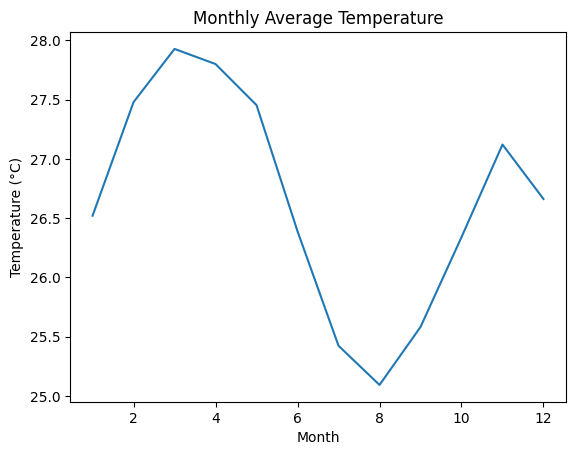

In [12]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(kind="line")
plt.title("Monthly Average Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

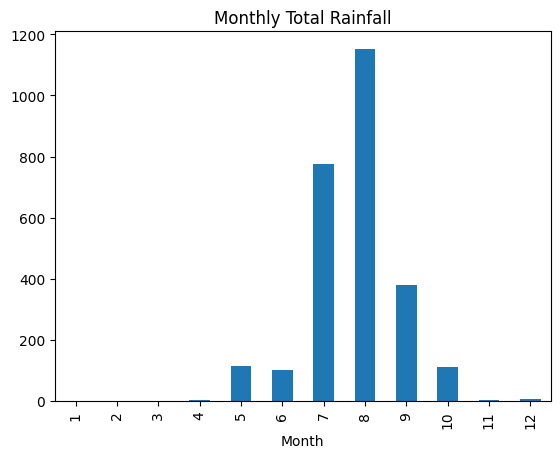

In [13]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Total Rainfall")
plt.show()

# 14. Correlation Heatmap
**Objective:** To identify the strength and direction of relationships between various meteorological variables to understand Nigeria’s latitudinal and monsoon-driven climate dynamics.

**Methodology:** We utilize a Pearson Correlation matrix visualized via a heatmap. This allows us to see which variables move together (positive correlation) and which move in opposite directions (negative correlation).

**Key Insights from Nigeria Dataset:**

**Intense Thermal Coupling:** A strong positive correlation exists between $T2M$ and $T2M\_MAX$ (0.93) and an even stronger one with $T2M\_MIN$ (0.94). This indicates that Nigeria's overall daily temperature is deeply tied to its nighttime minimums, characteristic of a high-humidity tropical environment where the atmosphere retains significant heat after sunset.

**The Humidity Buffer:** There is an exceptionally strong negative correlation (-0.81) between $RH2M$ (Relative Humidity) and $T2M\_RANGE$. This confirms that the high moisture levels prevalent across Nigeria act as a massive thermal stabilizer, suppressing extreme diurnal temperature swings. This is the core mechanism that separates Nigeria’s humid southern climate from the more volatile, arid northern Sahel.

**Dominant Moisture Content:** We observe a nearly perfect positive correlation (0.94) between specific humidity ($QV2M$) and relative humidity ($RH2M$). This suggests that Nigeria’s atmosphere remains consistently near saturation, with moisture levels being the primary driver of its climatic state, fueled by the persistent inflow of maritime air from the Gulf of Guinea.

**Wind Pattern Consistency:**  $WS2M$ and $WS2M\_MAX$ exhibit a very high correlation (0.90). This indicates that wind energy in Nigeria is remarkably consistent and predictable, likely following the seasonal migration of the West African Monsoon.

**Inverse Pressure-Temperature Relationship:** There is a robust negative correlation between $PS$ (Surface Pressure) and temperature variables, specifically -0.87 for $T2M$ and -0.81 for $T2M\_MIN$. This inverse relationship is a clear indicator of the thermal low-pressure systems that develop as temperatures rise, serving as a mechanical trigger for the convergence of moisture and subsequent monsoon rainfall.

**Conclusion for COP32:**  For Nigeria, the extreme coupling between humidity and temperature stability (correlation of -0.81) highlights its susceptibility to "wet-bulb" temperature risks—where high heat and humidity combine to limit the body's cooling ability. Furthermore, the near-perfect correlation between moisture variables (0.94) suggests that any disruption in maritime air circulation could lead to drastic shifts in Nigeria's rainfall patterns. Adaptation strategies must prioritize the monitoring of the Gulf of Guinea's surface temperatures, as the atmospheric correlations show that Nigeria’s entire thermal and hydrological cycle is anchored to this maritime moisture source.

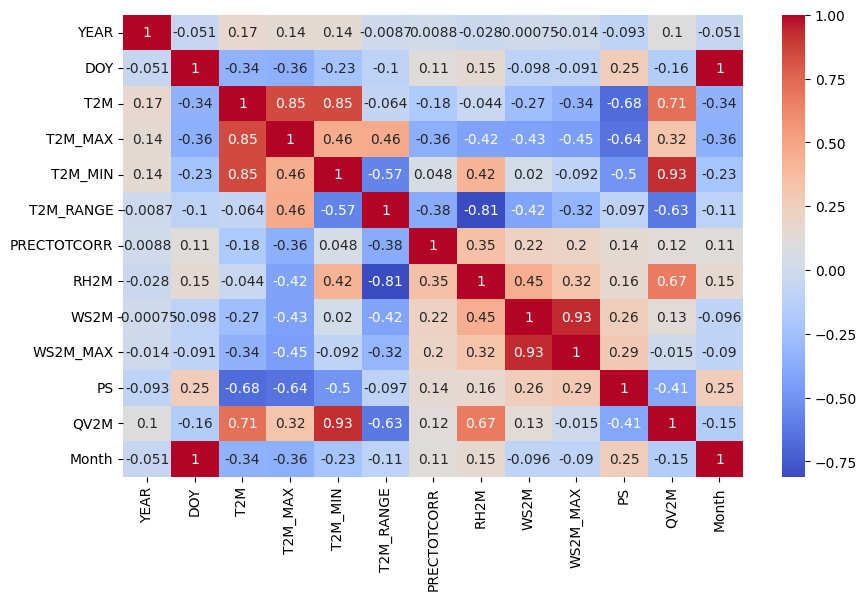

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

# 15. Relationship Analysis (Scatter Plots)

**Objective:** To visualize the interactions between primary climate drivers and identify non-linear patterns or clusters within the Nigerian dataset.

**A. Temperature (T2M) vs. Relative Humidity (RH2M)**
**Interpretation:** This plot illustrates a highly saturated tropical environment with a very tight coupling between heat and moisture.

**Observations:** The data shows an incredibly dense concentration of points between 25°C and 28°C, with relative humidity almost exclusively staying above 80%. Unlike Sudan’s "dry heat" or Tanzania’s slightly broader distribution, Nigeria’s atmosphere is locked into a high-humidity state.

**Climate Context:** This signature indicates a "latent heat" dominated environment. Because humidity is consistently near saturation, the air has a high heat capacity, which explains the very low temperature ranges observed. The lack of points in the lower-humidity quadrants confirms that Nigeria rarely experiences "dry" days, even at higher temperatures, leading to significant and persistent humid-heat stress.

**B. Temperature Range (T2M_RANGE) vs. Wind Speed (WS2M)**

**Interpretation:** The distribution is highly concentrated, reflecting a low-energy surface wind environment with minimal thermal variance.

**Observations:** The vast majority of data points are clustered at very low temperature ranges (below 6°C) and low wind speeds (predominantly between 1.5 and 3.0 m/s). There is a conspicuous absence of high-wind outliers, even when temperature ranges slightly expand.

**Physical Context:** In Nigeria, the lack of a strong correlation between temperature swings and wind speed suggests that surface winds are not primarily driven by local "thermal forcing" (the heating of the land). Instead, the environment is dominated by the steady, sluggish movement of the monsoonal air mass. This low-wind, low-swing profile suggests that natural ventilation is minimal, which, when combined with the high humidity seen in Plot A, exacerbates the regional climate’s impact on human health and urban heat islands.

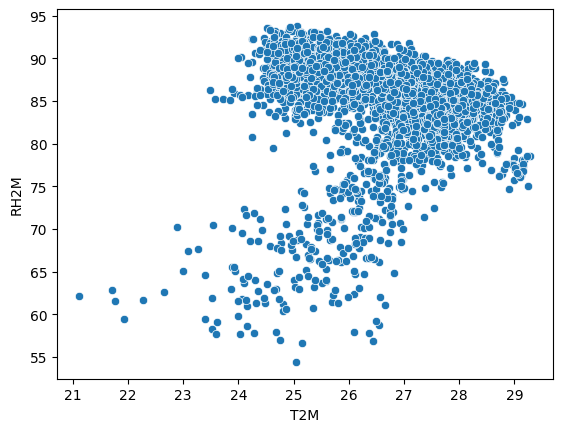

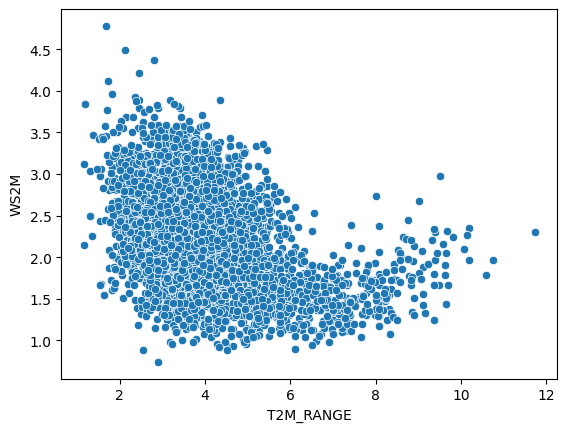

In [14]:
sns.scatterplot(x="T2M", y="RH2M", data=df)
plt.show()

sns.scatterplot(x="T2M_RANGE", y="WS2M", data=df)
plt.show()

# 16. Distribution Analysis (Precipitation)

**Objective:** To analyze the frequency and intensity of rainfall events across Tanzania to assess hydrological extremes, such as tropical depressions and severe flash-flood risks.

**Methodology:** We utilized a histogram with a Kernel Density Estimate (KDE) and a logarithmic scale on the y-axis (Count) to capture the full spectrum of precipitation events.

**Interpretation:**
**Bimodal Frequency Profile:** Unlike the hyper-arid profile of Sudan, Tanzania’s precipitation distribution shows a broader base. While zero-rain days still dominate the count, there is a higher frequency of moderate events (10–40 mm), reflecting the consistent moisture influx from the Indian Ocean.

**Extreme Outlier Events:** The logarithmic scale reveals an exceptional "long tail" reaching up to 122.65 mm/day. This is significantly higher than the maximums observed in Kenya or Sudan, indicating that Tanzania is susceptible to massive rainfall bursts, likely associated with tropical cyclones or intense ITCZ activity.

**KDE Oscillations:** The KDE curve exhibits several distinct "bumps" across the 20–80 mm range before the final taper. These fluctuations represent the varied nature of Tanzanian rainfall, from steady seasonal rains to high-intensity convective storms that occur with higher regularity than in the Sahelian North.

**Hydrological Resilience Note:** The extreme tail of the distribution, extending past 100 mm, underscores a significant risk of large-scale flooding. While Tanzania's humid soils may have higher absorption than Sudan's compacted earth, the sheer volume of these 100+ mm outliers presents a critical challenge for urban infrastructure and coastal management.

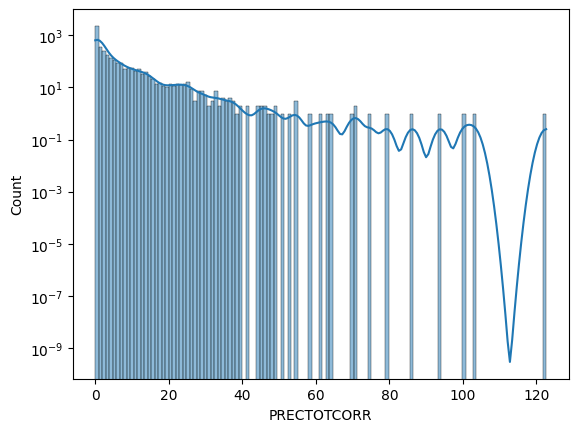

In [15]:
sns.histplot(df["PRECTOTCORR"], kde=True)
plt.yscale("log")
plt.show()

# 17. Multivariate Analysis (Bubble Chart)

**Objective:** To examine the three-way interaction between Temperature (T2M), Relative Humidity (RH2M), and Precipitation (PRECTOTCORR) to define Sudan's climatic "event envelope."

**Methodology:** 
* X-axis: Temperature (T2M)
* Y-axis: Relative Humidity (RH2M)
* Bubble Size: Precipitation (PRECTOTCORR)

**Interpretation:**
**Equatorial Rainfall Stability:**  In Tanzania, significant rainfall events (larger bubbles) occur across a broad temperature range, primarily between 24°C and 28°C. Unlike Sudan’s narrow thermal pocket, Tanzania’s rainfall is distributed across a high-humidity ceiling (80%–90%), reflecting the consistent influence of the ITCZ and maritime air masses.

**High-Humidity Baseline:** The chart lacks the "arid field" of small bubbles seen in the lower-right quadrant of the Sudan data. Instead, the vast majority of points—regardless of rainfall volume—are clustered above 70% humidity. This reinforces the finding that Tanzania maintains a moist environment even during periods of low precipitation.

**Consistent Heat-Moisture Coupling:** There is no "gap" in the upper-right quadrant; high humidity and moderate-to-high heat coexist frequently. In Tanzania, temperatures near 28°C are often paired with humidity levels above 85%, creating a sustained high wet-bulb temperature environment that is present during both rainy and dry intervals.

**Precipitation Density:** The distribution of large bubbles is dense and frequent, particularly where the Temperature-Humidity balance is most stable. This suggests that rainfall in Tanzania is a regular atmospheric process driven by steady maritime inflows, rather than the erratic, rare convective bursts observed in hyper-arid climates.


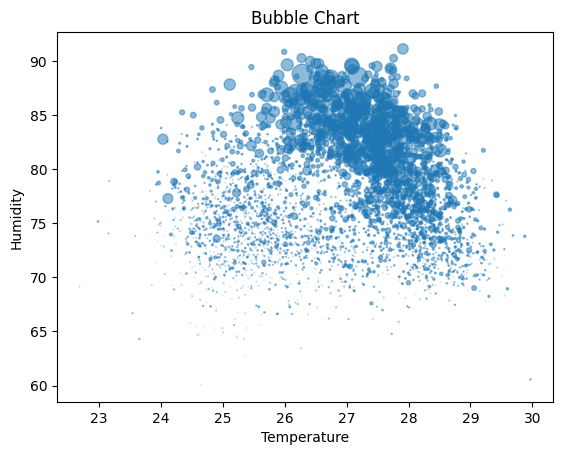

In [16]:
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*2, alpha=0.5)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Bubble Chart")
plt.show()